# Cleaning Data
If you want to type along with me, use [this notebook](https://humboldt.cloudbank.2i2c.cloud/hub/user-redirect/git-pull?repo=https%3A%2F%2Fgithub.com%2Fbethanyj0%2Fdata271_sp25&branch=main&urlpath=tree%2Fdata271_sp25%2Flectures%2Fdata271_lec27_live.ipynb) instead. 
If you don't want to type and want to follow along just by executing the cells, stay in this notebook. 

In [1]:
import numpy as np
import pandas as pd

In [2]:
# import the youtube data from last time
df = pd.read_csv('humboldt_youtube_2025.csv', dtype={'viewCount': 'object', 'likeCount':'object'})
df.head()

,etag,kind,videoId,publishedAt,channelId,title,description,default_url,default_width,default_height,...,medium_width,medium_height,high_url,high_width,high_height,channelTitle,liveBroadcastContent,publishTime,viewCount,likeCount
0,sQ5NDeYAHpbNJOKc7krGKs9IP3k,youtube#video,PoGnLtH1UHY,2025-04-01T17:26:59Z,UCg7Fdhrmwi8ZqakqiO3xPkg,Trio at Cal Poly Humboldt,"""We're here to support people, meet you where ...",https://i.ytimg.com/vi/PoGnLtH1UHY/default.jpg,120,90,...,320,180,https://i.ytimg.com/vi/PoGnLtH1UHY/hqdefault.jpg,480,360,HumboldtOnline,none,2025-04-01T17:26:59Z,27,2
1,8frtqOI_0dcOCINsANaOhri0fTk,youtube#video,u-PfB0FTmxI,2025-02-01T00:32:55Z,UCg7Fdhrmwi8ZqakqiO3xPkg,SOUNDCHECK: &quot;Yes or No&quot; - Cal Poly H...,"Yes or No” by Wayne Shorter, performed at soun...",https://i.ytimg.com/vi/u-PfB0FTmxI/default.jpg,120,90,...,320,180,https://i.ytimg.com/vi/u-PfB0FTmxI/hqdefault.jpg,480,360,HumboldtOnline,none,2025-02-01T00:32:55Z,164,20
2,_uQQJvfoAz7qZJYaOYyp0YEpkpU,youtube#video,90yFl295N9M,2024-12-21T04:43:58Z,UCg7Fdhrmwi8ZqakqiO3xPkg,Fall Commencement 2024,Congratulations to the Cal Poly Humboldt gradu...,https://i.ytimg.com/vi/90yFl295N9M/default.jpg,120,90,...,320,180,https://i.ytimg.com/vi/90yFl295N9M/hqdefault.jpg,480,360,HumboldtOnline,none,2024-12-21T04:43:58Z,90,4
3,FuC2K8Hl9XO9hcVRF0AAVqn_8fM,youtube#video,FTrKunStGOg,2024-12-11T20:29:04Z,UCg7Fdhrmwi8ZqakqiO3xPkg,Happy Holidays From Cal Poly Humboldt,"As we look ahead to the new year, students get...",https://i.ytimg.com/vi/FTrKunStGOg/default.jpg,120,90,...,320,180,https://i.ytimg.com/vi/FTrKunStGOg/hqdefault.jpg,480,360,HumboldtOnline,none,2024-12-11T20:29:04Z,2211,79
4,dz5BcVshPQtrCKBA_YUAcnfoqXU,youtube#video,Wkbj2V8CQTw,2024-10-17T23:08:59Z,UCg7Fdhrmwi8ZqakqiO3xPkg,Groundbreaking: Engineering &amp; Technology B...,Ushering in a new era for Northern California'...,https://i.ytimg.com/vi/Wkbj2V8CQTw/default.jpg,120,90,...,320,180,https://i.ytimg.com/vi/Wkbj2V8CQTw/hqdefault.jpg,480,360,HumboldtOnline,none,2024-10-17T23:08:59Z,355,5


## Cleaning the data 

In [3]:
# Check the column names
df.columns

Index(['etag', 'kind', 'videoId', 'publishedAt', 'channelId', 'title',
       'description', 'default_url', 'default_width', 'default_height',
       'medium_url', 'medium_width', 'medium_height', 'high_url', 'high_width',
       'high_height', 'channelTitle', 'liveBroadcastContent', 'publishTime',
       'viewCount', 'likeCount'],
      dtype='str')

In [4]:
# Inspect some questions
sum(df.publishedAt != df.publishTime)

0

In [5]:
# the two columns above are identical
df.drop(columns='publishTime',inplace=True)

In [6]:
# Check for any columns with just one value
df.nunique() == 1

etag                    False
kind                     True
videoId                 False
publishedAt             False
channelId                True
title                   False
description             False
default_url             False
default_width            True
default_height           True
medium_url              False
medium_width             True
medium_height            True
high_url                False
high_width               True
high_height              True
channelTitle             True
liveBroadcastContent     True
viewCount               False
likeCount               False
dtype: bool

In [7]:
# Save some relevant data, then remove redundant columns
channel_id = df.channelId[0]
chanel_title = df.channelTitle[0]

In [8]:
df = df.loc[:,df.nunique() > 1]

In [9]:
df.head()

,etag,videoId,publishedAt,title,description,default_url,medium_url,high_url,viewCount,likeCount
0,sQ5NDeYAHpbNJOKc7krGKs9IP3k,PoGnLtH1UHY,2025-04-01T17:26:59Z,Trio at Cal Poly Humboldt,"""We're here to support people, meet you where ...",https://i.ytimg.com/vi/PoGnLtH1UHY/default.jpg,https://i.ytimg.com/vi/PoGnLtH1UHY/mqdefault.jpg,https://i.ytimg.com/vi/PoGnLtH1UHY/hqdefault.jpg,27,2
1,8frtqOI_0dcOCINsANaOhri0fTk,u-PfB0FTmxI,2025-02-01T00:32:55Z,SOUNDCHECK: &quot;Yes or No&quot; - Cal Poly H...,"Yes or No” by Wayne Shorter, performed at soun...",https://i.ytimg.com/vi/u-PfB0FTmxI/default.jpg,https://i.ytimg.com/vi/u-PfB0FTmxI/mqdefault.jpg,https://i.ytimg.com/vi/u-PfB0FTmxI/hqdefault.jpg,164,20
2,_uQQJvfoAz7qZJYaOYyp0YEpkpU,90yFl295N9M,2024-12-21T04:43:58Z,Fall Commencement 2024,Congratulations to the Cal Poly Humboldt gradu...,https://i.ytimg.com/vi/90yFl295N9M/default.jpg,https://i.ytimg.com/vi/90yFl295N9M/mqdefault.jpg,https://i.ytimg.com/vi/90yFl295N9M/hqdefault.jpg,90,4
3,FuC2K8Hl9XO9hcVRF0AAVqn_8fM,FTrKunStGOg,2024-12-11T20:29:04Z,Happy Holidays From Cal Poly Humboldt,"As we look ahead to the new year, students get...",https://i.ytimg.com/vi/FTrKunStGOg/default.jpg,https://i.ytimg.com/vi/FTrKunStGOg/mqdefault.jpg,https://i.ytimg.com/vi/FTrKunStGOg/hqdefault.jpg,2211,79
4,dz5BcVshPQtrCKBA_YUAcnfoqXU,Wkbj2V8CQTw,2024-10-17T23:08:59Z,Groundbreaking: Engineering &amp; Technology B...,Ushering in a new era for Northern California'...,https://i.ytimg.com/vi/Wkbj2V8CQTw/default.jpg,https://i.ytimg.com/vi/Wkbj2V8CQTw/mqdefault.jpg,https://i.ytimg.com/vi/Wkbj2V8CQTw/hqdefault.jpg,355,5


### Reformat column names
Our columns names are in different formats. Let's fix that.

In [10]:
# OPTION 1 .rename method
df.rename(columns = {'videoId':'video_id',
                     'publishedAt':'published_at',
                     'viewCount':'view_count',
                     'likeCount':'like_count'}).head()

,etag,video_id,published_at,title,description,default_url,medium_url,high_url,view_count,like_count
0,sQ5NDeYAHpbNJOKc7krGKs9IP3k,PoGnLtH1UHY,2025-04-01T17:26:59Z,Trio at Cal Poly Humboldt,"""We're here to support people, meet you where ...",https://i.ytimg.com/vi/PoGnLtH1UHY/default.jpg,https://i.ytimg.com/vi/PoGnLtH1UHY/mqdefault.jpg,https://i.ytimg.com/vi/PoGnLtH1UHY/hqdefault.jpg,27,2
1,8frtqOI_0dcOCINsANaOhri0fTk,u-PfB0FTmxI,2025-02-01T00:32:55Z,SOUNDCHECK: &quot;Yes or No&quot; - Cal Poly H...,"Yes or No” by Wayne Shorter, performed at soun...",https://i.ytimg.com/vi/u-PfB0FTmxI/default.jpg,https://i.ytimg.com/vi/u-PfB0FTmxI/mqdefault.jpg,https://i.ytimg.com/vi/u-PfB0FTmxI/hqdefault.jpg,164,20
2,_uQQJvfoAz7qZJYaOYyp0YEpkpU,90yFl295N9M,2024-12-21T04:43:58Z,Fall Commencement 2024,Congratulations to the Cal Poly Humboldt gradu...,https://i.ytimg.com/vi/90yFl295N9M/default.jpg,https://i.ytimg.com/vi/90yFl295N9M/mqdefault.jpg,https://i.ytimg.com/vi/90yFl295N9M/hqdefault.jpg,90,4
3,FuC2K8Hl9XO9hcVRF0AAVqn_8fM,FTrKunStGOg,2024-12-11T20:29:04Z,Happy Holidays From Cal Poly Humboldt,"As we look ahead to the new year, students get...",https://i.ytimg.com/vi/FTrKunStGOg/default.jpg,https://i.ytimg.com/vi/FTrKunStGOg/mqdefault.jpg,https://i.ytimg.com/vi/FTrKunStGOg/hqdefault.jpg,2211,79
4,dz5BcVshPQtrCKBA_YUAcnfoqXU,Wkbj2V8CQTw,2024-10-17T23:08:59Z,Groundbreaking: Engineering &amp; Technology B...,Ushering in a new era for Northern California'...,https://i.ytimg.com/vi/Wkbj2V8CQTw/default.jpg,https://i.ytimg.com/vi/Wkbj2V8CQTw/mqdefault.jpg,https://i.ytimg.com/vi/Wkbj2V8CQTw/hqdefault.jpg,355,5


In [11]:
# does not update original (use inline=True)
df.head()

,etag,videoId,publishedAt,title,description,default_url,medium_url,high_url,viewCount,likeCount
0,sQ5NDeYAHpbNJOKc7krGKs9IP3k,PoGnLtH1UHY,2025-04-01T17:26:59Z,Trio at Cal Poly Humboldt,"""We're here to support people, meet you where ...",https://i.ytimg.com/vi/PoGnLtH1UHY/default.jpg,https://i.ytimg.com/vi/PoGnLtH1UHY/mqdefault.jpg,https://i.ytimg.com/vi/PoGnLtH1UHY/hqdefault.jpg,27,2
1,8frtqOI_0dcOCINsANaOhri0fTk,u-PfB0FTmxI,2025-02-01T00:32:55Z,SOUNDCHECK: &quot;Yes or No&quot; - Cal Poly H...,"Yes or No” by Wayne Shorter, performed at soun...",https://i.ytimg.com/vi/u-PfB0FTmxI/default.jpg,https://i.ytimg.com/vi/u-PfB0FTmxI/mqdefault.jpg,https://i.ytimg.com/vi/u-PfB0FTmxI/hqdefault.jpg,164,20
2,_uQQJvfoAz7qZJYaOYyp0YEpkpU,90yFl295N9M,2024-12-21T04:43:58Z,Fall Commencement 2024,Congratulations to the Cal Poly Humboldt gradu...,https://i.ytimg.com/vi/90yFl295N9M/default.jpg,https://i.ytimg.com/vi/90yFl295N9M/mqdefault.jpg,https://i.ytimg.com/vi/90yFl295N9M/hqdefault.jpg,90,4
3,FuC2K8Hl9XO9hcVRF0AAVqn_8fM,FTrKunStGOg,2024-12-11T20:29:04Z,Happy Holidays From Cal Poly Humboldt,"As we look ahead to the new year, students get...",https://i.ytimg.com/vi/FTrKunStGOg/default.jpg,https://i.ytimg.com/vi/FTrKunStGOg/mqdefault.jpg,https://i.ytimg.com/vi/FTrKunStGOg/hqdefault.jpg,2211,79
4,dz5BcVshPQtrCKBA_YUAcnfoqXU,Wkbj2V8CQTw,2024-10-17T23:08:59Z,Groundbreaking: Engineering &amp; Technology B...,Ushering in a new era for Northern California'...,https://i.ytimg.com/vi/Wkbj2V8CQTw/default.jpg,https://i.ytimg.com/vi/Wkbj2V8CQTw/mqdefault.jpg,https://i.ytimg.com/vi/Wkbj2V8CQTw/hqdefault.jpg,355,5


In [12]:
# OPTION 2: more general approach that would work for many columns
# Split column names by words
import re
split_by_words = [re.split('(?=[A-Z])',i) for i in df.columns]
split_by_words

[['etag'],
 ['video', 'Id'],
 ['published', 'At'],
 ['title'],
 ['description'],
 ['default_url'],
 ['medium_url'],
 ['high_url'],
 ['view', 'Count'],
 ['like', 'Count']]

In [13]:
# Insert an underscore between words
columns_with_underscores = ['_'.join(i).lower() for i in split_by_words]
columns_with_underscores

['etag',
 'video_id',
 'published_at',
 'title',
 'description',
 'default_url',
 'medium_url',
 'high_url',
 'view_count',
 'like_count']

In [14]:
# Reassign column names
df.columns = columns_with_underscores

In [15]:
df.head()

,etag,video_id,published_at,title,description,default_url,medium_url,high_url,view_count,like_count
0,sQ5NDeYAHpbNJOKc7krGKs9IP3k,PoGnLtH1UHY,2025-04-01T17:26:59Z,Trio at Cal Poly Humboldt,"""We're here to support people, meet you where ...",https://i.ytimg.com/vi/PoGnLtH1UHY/default.jpg,https://i.ytimg.com/vi/PoGnLtH1UHY/mqdefault.jpg,https://i.ytimg.com/vi/PoGnLtH1UHY/hqdefault.jpg,27,2
1,8frtqOI_0dcOCINsANaOhri0fTk,u-PfB0FTmxI,2025-02-01T00:32:55Z,SOUNDCHECK: &quot;Yes or No&quot; - Cal Poly H...,"Yes or No” by Wayne Shorter, performed at soun...",https://i.ytimg.com/vi/u-PfB0FTmxI/default.jpg,https://i.ytimg.com/vi/u-PfB0FTmxI/mqdefault.jpg,https://i.ytimg.com/vi/u-PfB0FTmxI/hqdefault.jpg,164,20
2,_uQQJvfoAz7qZJYaOYyp0YEpkpU,90yFl295N9M,2024-12-21T04:43:58Z,Fall Commencement 2024,Congratulations to the Cal Poly Humboldt gradu...,https://i.ytimg.com/vi/90yFl295N9M/default.jpg,https://i.ytimg.com/vi/90yFl295N9M/mqdefault.jpg,https://i.ytimg.com/vi/90yFl295N9M/hqdefault.jpg,90,4
3,FuC2K8Hl9XO9hcVRF0AAVqn_8fM,FTrKunStGOg,2024-12-11T20:29:04Z,Happy Holidays From Cal Poly Humboldt,"As we look ahead to the new year, students get...",https://i.ytimg.com/vi/FTrKunStGOg/default.jpg,https://i.ytimg.com/vi/FTrKunStGOg/mqdefault.jpg,https://i.ytimg.com/vi/FTrKunStGOg/hqdefault.jpg,2211,79
4,dz5BcVshPQtrCKBA_YUAcnfoqXU,Wkbj2V8CQTw,2024-10-17T23:08:59Z,Groundbreaking: Engineering &amp; Technology B...,Ushering in a new era for Northern California'...,https://i.ytimg.com/vi/Wkbj2V8CQTw/default.jpg,https://i.ytimg.com/vi/Wkbj2V8CQTw/mqdefault.jpg,https://i.ytimg.com/vi/Wkbj2V8CQTw/hqdefault.jpg,355,5


### Convert datatypes

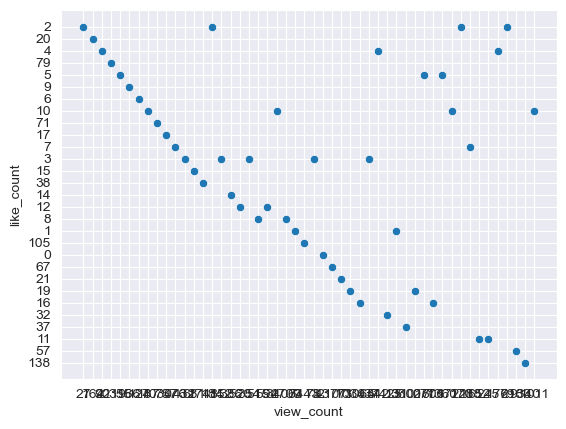

In [16]:
# Suppose we wanted to look at the relationship between view counts and like counts
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')
sns.scatterplot(data = df, x='view_count',y='like_count')
plt.show()

In [17]:
# Something is funky. Check the data types
df.dtypes

etag               str
video_id           str
published_at       str
title              str
description        str
default_url        str
medium_url         str
high_url           str
view_count      object
like_count      object
dtype: object

In [18]:
# convert the data types
df = df.astype({'view_count':int, 'like_count':int})

In [19]:
# check data types again
df.dtypes

etag              str
video_id          str
published_at      str
title             str
description       str
default_url       str
medium_url        str
high_url          str
view_count      int64
like_count      int64
dtype: object

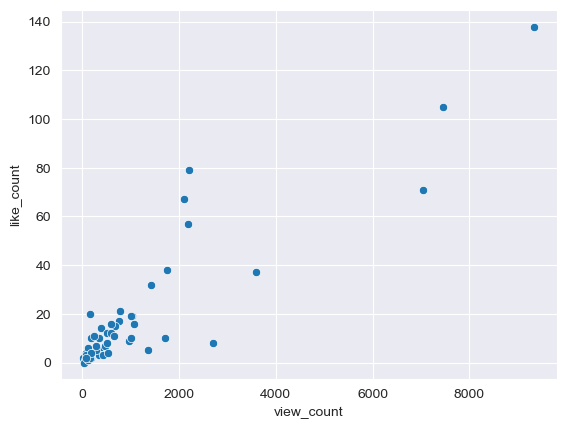

In [20]:
# plot again
sns.scatterplot(data = df, x='view_count',y='like_count')
plt.show()

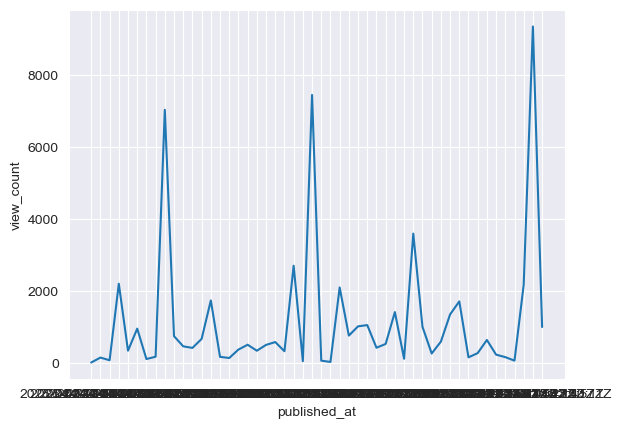

In [21]:
# What if we wanted to plot trend in view counts?
sns.lineplot(data = df, x='published_at',y='view_count')
plt.show()

In [22]:
# change dates to datetime data
df['published_at'] = pd.to_datetime(df.published_at)
df.head()

,etag,video_id,published_at,title,description,default_url,medium_url,high_url,view_count,like_count
0,sQ5NDeYAHpbNJOKc7krGKs9IP3k,PoGnLtH1UHY,2025-04-01 17:26:59+00:00,Trio at Cal Poly Humboldt,"""We're here to support people, meet you where ...",https://i.ytimg.com/vi/PoGnLtH1UHY/default.jpg,https://i.ytimg.com/vi/PoGnLtH1UHY/mqdefault.jpg,https://i.ytimg.com/vi/PoGnLtH1UHY/hqdefault.jpg,27,2
1,8frtqOI_0dcOCINsANaOhri0fTk,u-PfB0FTmxI,2025-02-01 00:32:55+00:00,SOUNDCHECK: &quot;Yes or No&quot; - Cal Poly H...,"Yes or No” by Wayne Shorter, performed at soun...",https://i.ytimg.com/vi/u-PfB0FTmxI/default.jpg,https://i.ytimg.com/vi/u-PfB0FTmxI/mqdefault.jpg,https://i.ytimg.com/vi/u-PfB0FTmxI/hqdefault.jpg,164,20
2,_uQQJvfoAz7qZJYaOYyp0YEpkpU,90yFl295N9M,2024-12-21 04:43:58+00:00,Fall Commencement 2024,Congratulations to the Cal Poly Humboldt gradu...,https://i.ytimg.com/vi/90yFl295N9M/default.jpg,https://i.ytimg.com/vi/90yFl295N9M/mqdefault.jpg,https://i.ytimg.com/vi/90yFl295N9M/hqdefault.jpg,90,4
3,FuC2K8Hl9XO9hcVRF0AAVqn_8fM,FTrKunStGOg,2024-12-11 20:29:04+00:00,Happy Holidays From Cal Poly Humboldt,"As we look ahead to the new year, students get...",https://i.ytimg.com/vi/FTrKunStGOg/default.jpg,https://i.ytimg.com/vi/FTrKunStGOg/mqdefault.jpg,https://i.ytimg.com/vi/FTrKunStGOg/hqdefault.jpg,2211,79
4,dz5BcVshPQtrCKBA_YUAcnfoqXU,Wkbj2V8CQTw,2024-10-17 23:08:59+00:00,Groundbreaking: Engineering &amp; Technology B...,Ushering in a new era for Northern California'...,https://i.ytimg.com/vi/Wkbj2V8CQTw/default.jpg,https://i.ytimg.com/vi/Wkbj2V8CQTw/mqdefault.jpg,https://i.ytimg.com/vi/Wkbj2V8CQTw/hqdefault.jpg,355,5


In [23]:
# Check dtypes again
df.dtypes

etag                            str
video_id                        str
published_at    datetime64[us, UTC]
title                           str
description                     str
default_url                     str
medium_url                      str
high_url                        str
view_count                    int64
like_count                    int64
dtype: object

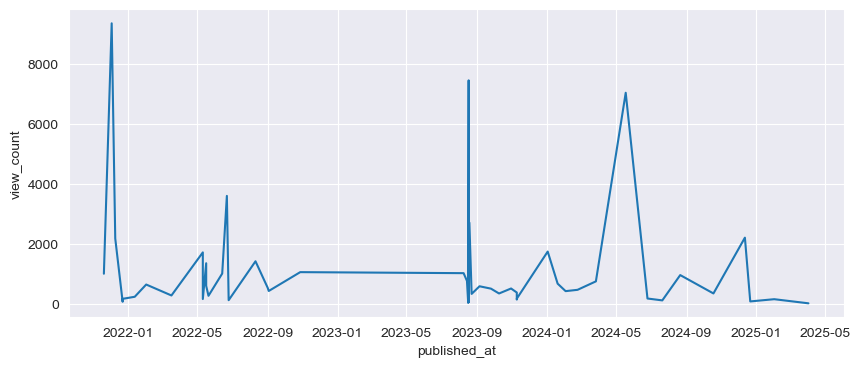

In [24]:
# plot again
plt.figure(figsize = (10,4))
sns.lineplot(data = df, x='published_at',y='view_count')
plt.show()

#### More on working with dates
Pandas datetime types can be interpreted in multiple formats

In [25]:
date1 = 'April 5, 2025'
pd.to_datetime(date1, format = '%B %d, %Y')

Timestamp('2025-04-05 00:00:00')

In [26]:
date2 = 'Apr 5, 2025'
pd.to_datetime(date2, format = '%b %d, %Y')

Timestamp('2025-04-05 00:00:00')

In [27]:
date3 = '4/5/25'
pd.to_datetime(date3, format = '%m/%d/%y')

Timestamp('2025-04-05 00:00:00')

In [28]:
date4 = '5-4-25'
pd.to_datetime(date4, format = '%d-%m-%y')

Timestamp('2025-04-05 00:00:00')

In [29]:
date5 = '4-5-2025'
pd.to_datetime(date5, format = '%m-%d-%Y')

Timestamp('2025-04-05 00:00:00')

In [30]:
date6 = '4-05-2025'
pd.to_datetime(date5, format = '%m-%d-%Y')

Timestamp('2025-04-05 00:00:00')

Use [this reference](https://docs.python.org/3/library/datetime.html#strftime-and-strptime-behavior) for more info about datetime formats. 

### Reset the index

In [31]:
# Reset the index for easy access by video id
df.set_index('video_id',inplace=True)
df.head()

,etag,published_at,title,description,default_url,medium_url,high_url,view_count,like_count
video_id,,,,,,,,,
PoGnLtH1UHY,sQ5NDeYAHpbNJOKc7krGKs9IP3k,2025-04-01 17:26:59+00:00,Trio at Cal Poly Humboldt,"""We're here to support people, meet you where ...",https://i.ytimg.com/vi/PoGnLtH1UHY/default.jpg,https://i.ytimg.com/vi/PoGnLtH1UHY/mqdefault.jpg,https://i.ytimg.com/vi/PoGnLtH1UHY/hqdefault.jpg,27,2
u-PfB0FTmxI,8frtqOI_0dcOCINsANaOhri0fTk,2025-02-01 00:32:55+00:00,SOUNDCHECK: &quot;Yes or No&quot; - Cal Poly H...,"Yes or No” by Wayne Shorter, performed at soun...",https://i.ytimg.com/vi/u-PfB0FTmxI/default.jpg,https://i.ytimg.com/vi/u-PfB0FTmxI/mqdefault.jpg,https://i.ytimg.com/vi/u-PfB0FTmxI/hqdefault.jpg,164,20
90yFl295N9M,_uQQJvfoAz7qZJYaOYyp0YEpkpU,2024-12-21 04:43:58+00:00,Fall Commencement 2024,Congratulations to the Cal Poly Humboldt gradu...,https://i.ytimg.com/vi/90yFl295N9M/default.jpg,https://i.ytimg.com/vi/90yFl295N9M/mqdefault.jpg,https://i.ytimg.com/vi/90yFl295N9M/hqdefault.jpg,90,4
FTrKunStGOg,FuC2K8Hl9XO9hcVRF0AAVqn_8fM,2024-12-11 20:29:04+00:00,Happy Holidays From Cal Poly Humboldt,"As we look ahead to the new year, students get...",https://i.ytimg.com/vi/FTrKunStGOg/default.jpg,https://i.ytimg.com/vi/FTrKunStGOg/mqdefault.jpg,https://i.ytimg.com/vi/FTrKunStGOg/hqdefault.jpg,2211,79
Wkbj2V8CQTw,dz5BcVshPQtrCKBA_YUAcnfoqXU,2024-10-17 23:08:59+00:00,Groundbreaking: Engineering &amp; Technology B...,Ushering in a new era for Northern California'...,https://i.ytimg.com/vi/Wkbj2V8CQTw/default.jpg,https://i.ytimg.com/vi/Wkbj2V8CQTw/mqdefault.jpg,https://i.ytimg.com/vi/Wkbj2V8CQTw/hqdefault.jpg,355,5


In [32]:
# index by video id
video_id = "PoGnLtH1UHY"
df.loc[video_id]

etag                                  sQ5NDeYAHpbNJOKc7krGKs9IP3k
published_at                            2025-04-01 17:26:59+00:00
title                                   Trio at Cal Poly Humboldt
description     "We're here to support people, meet you where ...
default_url        https://i.ytimg.com/vi/PoGnLtH1UHY/default.jpg
medium_url       https://i.ytimg.com/vi/PoGnLtH1UHY/mqdefault.jpg
high_url         https://i.ytimg.com/vi/PoGnLtH1UHY/hqdefault.jpg
view_count                                                     27
like_count                                                      2
Name: PoGnLtH1UHY, dtype: object

In [33]:
df.loc[df.view_count.idxmax()]

etag                                  EVjY39F6DOvRc4tMFANjz3qb8P4
published_at                            2021-12-02 18:25:57+00:00
title                           Humboldt&#39;s Polytechnic Vision
description     Science with a soul: Humboldt is reimagining a...
default_url        https://i.ytimg.com/vi/E2ahIKFLTys/default.jpg
medium_url       https://i.ytimg.com/vi/E2ahIKFLTys/mqdefault.jpg
high_url         https://i.ytimg.com/vi/E2ahIKFLTys/hqdefault.jpg
view_count                                                   9340
like_count                                                    138
Name: E2ahIKFLTys, dtype: object

### Reorder the data

In [34]:
# reorder rows
df.sort_index(axis=0).head()

,etag,published_at,title,description,default_url,medium_url,high_url,view_count,like_count
video_id,,,,,,,,,
00oRFzD-A6c,SvjAiqOw2lob5WgPlN6plqd0k8k,2023-08-14 19:02:51+00:00,Learning In and From the Environment,Join us on a journey through tomorrow's soluti...,https://i.ytimg.com/vi/00oRFzD-A6c/default.jpg,https://i.ytimg.com/vi/00oRFzD-A6c/mqdefault.jpg,https://i.ytimg.com/vi/00oRFzD-A6c/hqdefault.jpg,773,21
02dnAkMHRYY,Rz7WmhEZWT0WC3FnGdwS0y04P3M,2022-01-31 23:56:04+00:00,Meet the Students Helping Kelp Come Back,Cal Poly Humboldt graduate students Kalani Ort...,https://i.ytimg.com/vi/02dnAkMHRYY/default.jpg,https://i.ytimg.com/vi/02dnAkMHRYY/mqdefault.jpg,https://i.ytimg.com/vi/02dnAkMHRYY/hqdefault.jpg,652,11
0D79QvI5c34,wNqjlr6H3DTVGZ4rqAapQdOQLT0,2024-06-24 19:55:59+00:00,Take a hike! #CalPolyHumboldt #Redwoods #HikeW...,Happy #HikeWithAGeekDay! We hope you had the c...,https://i.ytimg.com/vi/0D79QvI5c34/default.jpg,https://i.ytimg.com/vi/0D79QvI5c34/mqdefault.jpg,https://i.ytimg.com/vi/0D79QvI5c34/hqdefault.jpg,187,10
0VVd42ErYz0,P6TQXDJbM74saHPfq4VSFL2fLWw,2022-08-10 18:08:19+00:00,Deep In The Klamath,In the leadup to the world's largest dam remov...,https://i.ytimg.com/vi/0VVd42ErYz0/default.jpg,https://i.ytimg.com/vi/0VVd42ErYz0/mqdefault.jpg,https://i.ytimg.com/vi/0VVd42ErYz0/hqdefault.jpg,1425,32
0ZpK55S4wBc,8_RSotgRCwZq8MntIviUuggUcKI,2022-09-02 20:59:42+00:00,College Colors Day!,The Cal Poly Humboldt family had a picnic on t...,https://i.ytimg.com/vi/0ZpK55S4wBc/default.jpg,https://i.ytimg.com/vi/0ZpK55S4wBc/mqdefault.jpg,https://i.ytimg.com/vi/0ZpK55S4wBc/hqdefault.jpg,437,3


In [35]:
# doesn't update original
df.head()

,etag,published_at,title,description,default_url,medium_url,high_url,view_count,like_count
video_id,,,,,,,,,
PoGnLtH1UHY,sQ5NDeYAHpbNJOKc7krGKs9IP3k,2025-04-01 17:26:59+00:00,Trio at Cal Poly Humboldt,"""We're here to support people, meet you where ...",https://i.ytimg.com/vi/PoGnLtH1UHY/default.jpg,https://i.ytimg.com/vi/PoGnLtH1UHY/mqdefault.jpg,https://i.ytimg.com/vi/PoGnLtH1UHY/hqdefault.jpg,27,2
u-PfB0FTmxI,8frtqOI_0dcOCINsANaOhri0fTk,2025-02-01 00:32:55+00:00,SOUNDCHECK: &quot;Yes or No&quot; - Cal Poly H...,"Yes or No” by Wayne Shorter, performed at soun...",https://i.ytimg.com/vi/u-PfB0FTmxI/default.jpg,https://i.ytimg.com/vi/u-PfB0FTmxI/mqdefault.jpg,https://i.ytimg.com/vi/u-PfB0FTmxI/hqdefault.jpg,164,20
90yFl295N9M,_uQQJvfoAz7qZJYaOYyp0YEpkpU,2024-12-21 04:43:58+00:00,Fall Commencement 2024,Congratulations to the Cal Poly Humboldt gradu...,https://i.ytimg.com/vi/90yFl295N9M/default.jpg,https://i.ytimg.com/vi/90yFl295N9M/mqdefault.jpg,https://i.ytimg.com/vi/90yFl295N9M/hqdefault.jpg,90,4
FTrKunStGOg,FuC2K8Hl9XO9hcVRF0AAVqn_8fM,2024-12-11 20:29:04+00:00,Happy Holidays From Cal Poly Humboldt,"As we look ahead to the new year, students get...",https://i.ytimg.com/vi/FTrKunStGOg/default.jpg,https://i.ytimg.com/vi/FTrKunStGOg/mqdefault.jpg,https://i.ytimg.com/vi/FTrKunStGOg/hqdefault.jpg,2211,79
Wkbj2V8CQTw,dz5BcVshPQtrCKBA_YUAcnfoqXU,2024-10-17 23:08:59+00:00,Groundbreaking: Engineering &amp; Technology B...,Ushering in a new era for Northern California'...,https://i.ytimg.com/vi/Wkbj2V8CQTw/default.jpg,https://i.ytimg.com/vi/Wkbj2V8CQTw/mqdefault.jpg,https://i.ytimg.com/vi/Wkbj2V8CQTw/hqdefault.jpg,355,5


In [36]:
# reorder columns
df.sort_index(axis=1).head()

,default_url,description,etag,high_url,like_count,medium_url,published_at,title,view_count
video_id,,,,,,,,,
PoGnLtH1UHY,https://i.ytimg.com/vi/PoGnLtH1UHY/default.jpg,"""We're here to support people, meet you where ...",sQ5NDeYAHpbNJOKc7krGKs9IP3k,https://i.ytimg.com/vi/PoGnLtH1UHY/hqdefault.jpg,2,https://i.ytimg.com/vi/PoGnLtH1UHY/mqdefault.jpg,2025-04-01 17:26:59+00:00,Trio at Cal Poly Humboldt,27
u-PfB0FTmxI,https://i.ytimg.com/vi/u-PfB0FTmxI/default.jpg,"Yes or No” by Wayne Shorter, performed at soun...",8frtqOI_0dcOCINsANaOhri0fTk,https://i.ytimg.com/vi/u-PfB0FTmxI/hqdefault.jpg,20,https://i.ytimg.com/vi/u-PfB0FTmxI/mqdefault.jpg,2025-02-01 00:32:55+00:00,SOUNDCHECK: &quot;Yes or No&quot; - Cal Poly H...,164
90yFl295N9M,https://i.ytimg.com/vi/90yFl295N9M/default.jpg,Congratulations to the Cal Poly Humboldt gradu...,_uQQJvfoAz7qZJYaOYyp0YEpkpU,https://i.ytimg.com/vi/90yFl295N9M/hqdefault.jpg,4,https://i.ytimg.com/vi/90yFl295N9M/mqdefault.jpg,2024-12-21 04:43:58+00:00,Fall Commencement 2024,90
FTrKunStGOg,https://i.ytimg.com/vi/FTrKunStGOg/default.jpg,"As we look ahead to the new year, students get...",FuC2K8Hl9XO9hcVRF0AAVqn_8fM,https://i.ytimg.com/vi/FTrKunStGOg/hqdefault.jpg,79,https://i.ytimg.com/vi/FTrKunStGOg/mqdefault.jpg,2024-12-11 20:29:04+00:00,Happy Holidays From Cal Poly Humboldt,2211
Wkbj2V8CQTw,https://i.ytimg.com/vi/Wkbj2V8CQTw/default.jpg,Ushering in a new era for Northern California'...,dz5BcVshPQtrCKBA_YUAcnfoqXU,https://i.ytimg.com/vi/Wkbj2V8CQTw/hqdefault.jpg,5,https://i.ytimg.com/vi/Wkbj2V8CQTw/mqdefault.jpg,2024-10-17 23:08:59+00:00,Groundbreaking: Engineering &amp; Technology B...,355


In [37]:
# Place columns in your chosen order
df[['view_count','like_count','published_at','title']].head()

,view_count,like_count,published_at,title
video_id,,,,
PoGnLtH1UHY,27,2,2025-04-01 17:26:59+00:00,Trio at Cal Poly Humboldt
u-PfB0FTmxI,164,20,2025-02-01 00:32:55+00:00,SOUNDCHECK: &quot;Yes or No&quot; - Cal Poly H...
90yFl295N9M,90,4,2024-12-21 04:43:58+00:00,Fall Commencement 2024
FTrKunStGOg,2211,79,2024-12-11 20:29:04+00:00,Happy Holidays From Cal Poly Humboldt
Wkbj2V8CQTw,355,5,2024-10-17 23:08:59+00:00,Groundbreaking: Engineering &amp; Technology B...


In [38]:
# sort the data 
df.sort_values(by='view_count').head()

,etag,published_at,title,description,default_url,medium_url,high_url,view_count,like_count
video_id,,,,,,,,,
PoGnLtH1UHY,sQ5NDeYAHpbNJOKc7krGKs9IP3k,2025-04-01 17:26:59+00:00,Trio at Cal Poly Humboldt,"""We're here to support people, meet you where ...",https://i.ytimg.com/vi/PoGnLtH1UHY/default.jpg,https://i.ytimg.com/vi/PoGnLtH1UHY/mqdefault.jpg,https://i.ytimg.com/vi/PoGnLtH1UHY/hqdefault.jpg,27,2
OAr-3isYAAA,Yu7DsB_dNENy1k1dKYqSVf11mpw,2023-08-16 20:18:08+00:00,Healthcare Education Hub Press Conference,Senator Mike McGuire and collaborators from Ca...,https://i.ytimg.com/vi/OAr-3isYAAA/default.jpg,https://i.ytimg.com/vi/OAr-3isYAAA/mqdefault.jpg,https://i.ytimg.com/vi/OAr-3isYAAA/hqdefault.jpg,43,0
EFUd5aNVo58,CarIf_sWKZP-R34qn39pXnvHZs0,2023-08-17 21:38:21+00:00,Protecting Culture from the Ground Up,"The Cultural Resources Facility (CRF) studies,...",https://i.ytimg.com/vi/EFUd5aNVo58/default.jpg,https://i.ytimg.com/vi/EFUd5aNVo58/mqdefault.jpg,https://i.ytimg.com/vi/EFUd5aNVo58/hqdefault.jpg,63,1
b-ceo-H9dWg,au75YG8Eawx7lSzZRHCAb07d1RU,2023-08-16 20:17:46+00:00,Training the next generation of stem cell scie...,Cal Poly Humboldt's CIRM Bridges Program is de...,https://i.ytimg.com/vi/b-ceo-H9dWg/default.jpg,https://i.ytimg.com/vi/b-ceo-H9dWg/mqdefault.jpg,https://i.ytimg.com/vi/b-ceo-H9dWg/hqdefault.jpg,78,3
TT1Ve-FN6Us,5gxXmOmhn0JqLlf2ydYIoJPuZx0,2021-12-21 21:03:11+00:00,A Mixed-media Masterclass,The Art & Film department's Fall Open House wa...,https://i.ytimg.com/vi/TT1Ve-FN6Us/default.jpg,https://i.ytimg.com/vi/TT1Ve-FN6Us/mqdefault.jpg,https://i.ytimg.com/vi/TT1Ve-FN6Us/hqdefault.jpg,79,2


In [39]:
# doesn't update original
df.head()

,etag,published_at,title,description,default_url,medium_url,high_url,view_count,like_count
video_id,,,,,,,,,
PoGnLtH1UHY,sQ5NDeYAHpbNJOKc7krGKs9IP3k,2025-04-01 17:26:59+00:00,Trio at Cal Poly Humboldt,"""We're here to support people, meet you where ...",https://i.ytimg.com/vi/PoGnLtH1UHY/default.jpg,https://i.ytimg.com/vi/PoGnLtH1UHY/mqdefault.jpg,https://i.ytimg.com/vi/PoGnLtH1UHY/hqdefault.jpg,27,2
u-PfB0FTmxI,8frtqOI_0dcOCINsANaOhri0fTk,2025-02-01 00:32:55+00:00,SOUNDCHECK: &quot;Yes or No&quot; - Cal Poly H...,"Yes or No” by Wayne Shorter, performed at soun...",https://i.ytimg.com/vi/u-PfB0FTmxI/default.jpg,https://i.ytimg.com/vi/u-PfB0FTmxI/mqdefault.jpg,https://i.ytimg.com/vi/u-PfB0FTmxI/hqdefault.jpg,164,20
90yFl295N9M,_uQQJvfoAz7qZJYaOYyp0YEpkpU,2024-12-21 04:43:58+00:00,Fall Commencement 2024,Congratulations to the Cal Poly Humboldt gradu...,https://i.ytimg.com/vi/90yFl295N9M/default.jpg,https://i.ytimg.com/vi/90yFl295N9M/mqdefault.jpg,https://i.ytimg.com/vi/90yFl295N9M/hqdefault.jpg,90,4
FTrKunStGOg,FuC2K8Hl9XO9hcVRF0AAVqn_8fM,2024-12-11 20:29:04+00:00,Happy Holidays From Cal Poly Humboldt,"As we look ahead to the new year, students get...",https://i.ytimg.com/vi/FTrKunStGOg/default.jpg,https://i.ytimg.com/vi/FTrKunStGOg/mqdefault.jpg,https://i.ytimg.com/vi/FTrKunStGOg/hqdefault.jpg,2211,79
Wkbj2V8CQTw,dz5BcVshPQtrCKBA_YUAcnfoqXU,2024-10-17 23:08:59+00:00,Groundbreaking: Engineering &amp; Technology B...,Ushering in a new era for Northern California'...,https://i.ytimg.com/vi/Wkbj2V8CQTw/default.jpg,https://i.ytimg.com/vi/Wkbj2V8CQTw/mqdefault.jpg,https://i.ytimg.com/vi/Wkbj2V8CQTw/hqdefault.jpg,355,5


In [40]:
# do it inplace
df.sort_values(by = 'view_count',ascending=False, inplace=True)

In [41]:
df.head()

,etag,published_at,title,description,default_url,medium_url,high_url,view_count,like_count
video_id,,,,,,,,,
E2ahIKFLTys,EVjY39F6DOvRc4tMFANjz3qb8P4,2021-12-02 18:25:57+00:00,Humboldt&#39;s Polytechnic Vision,Science with a soul: Humboldt is reimagining a...,https://i.ytimg.com/vi/E2ahIKFLTys/default.jpg,https://i.ytimg.com/vi/E2ahIKFLTys/mqdefault.jpg,https://i.ytimg.com/vi/E2ahIKFLTys/hqdefault.jpg,9340,138
1xhlzwUn9tE,AeBgAbCiv98ir_Mg-rb3Nbb9Mbs,2023-08-17 18:18:22+00:00,Future Found: Cal Poly Humboldt,Education from the ground up. A hands-on acade...,https://i.ytimg.com/vi/1xhlzwUn9tE/default.jpg,https://i.ytimg.com/vi/1xhlzwUn9tE/mqdefault.jpg,https://i.ytimg.com/vi/1xhlzwUn9tE/hqdefault.jpg,7443,105
FBPPTlCyl_I,VUvjc2rZLEsDOV_TWl-gj-uNY3s,2024-05-17 20:35:16+00:00,Living on Campus at Cal Poly Humboldt,Where should you live on campus at Cal Poly Hu...,https://i.ytimg.com/vi/FBPPTlCyl_I/default.jpg,https://i.ytimg.com/vi/FBPPTlCyl_I/mqdefault.jpg,https://i.ytimg.com/vi/FBPPTlCyl_I/hqdefault.jpg,7030,71
As3iX6sU-vY,-Dgpv8GHiGLJuZ0NdFiNmw2vq80,2022-06-21 18:51:12+00:00,"Solar Microgrids, Explained","Here at Cal Poly Humboldt, the Schatz Energy R...",https://i.ytimg.com/vi/As3iX6sU-vY/default.jpg,https://i.ytimg.com/vi/As3iX6sU-vY/mqdefault.jpg,https://i.ytimg.com/vi/As3iX6sU-vY/hqdefault.jpg,3600,37
_V7S0NRr6nQ,qFBD_5_6sDOy0Zc8v6ztUeporyg,2023-08-19 00:46:35+00:00,Move-In and Orientation Week!,New students have been busy - and they're just...,https://i.ytimg.com/vi/_V7S0NRr6nQ/default.jpg,https://i.ytimg.com/vi/_V7S0NRr6nQ/mqdefault.jpg,https://i.ytimg.com/vi/_V7S0NRr6nQ/hqdefault.jpg,2709,8


In [42]:
# sort by multiple values at once
df.sort_values(by = ['view_count','like_count'],ascending=[False,True], inplace=True)
df.head()

,etag,published_at,title,description,default_url,medium_url,high_url,view_count,like_count
video_id,,,,,,,,,
E2ahIKFLTys,EVjY39F6DOvRc4tMFANjz3qb8P4,2021-12-02 18:25:57+00:00,Humboldt&#39;s Polytechnic Vision,Science with a soul: Humboldt is reimagining a...,https://i.ytimg.com/vi/E2ahIKFLTys/default.jpg,https://i.ytimg.com/vi/E2ahIKFLTys/mqdefault.jpg,https://i.ytimg.com/vi/E2ahIKFLTys/hqdefault.jpg,9340,138
1xhlzwUn9tE,AeBgAbCiv98ir_Mg-rb3Nbb9Mbs,2023-08-17 18:18:22+00:00,Future Found: Cal Poly Humboldt,Education from the ground up. A hands-on acade...,https://i.ytimg.com/vi/1xhlzwUn9tE/default.jpg,https://i.ytimg.com/vi/1xhlzwUn9tE/mqdefault.jpg,https://i.ytimg.com/vi/1xhlzwUn9tE/hqdefault.jpg,7443,105
FBPPTlCyl_I,VUvjc2rZLEsDOV_TWl-gj-uNY3s,2024-05-17 20:35:16+00:00,Living on Campus at Cal Poly Humboldt,Where should you live on campus at Cal Poly Hu...,https://i.ytimg.com/vi/FBPPTlCyl_I/default.jpg,https://i.ytimg.com/vi/FBPPTlCyl_I/mqdefault.jpg,https://i.ytimg.com/vi/FBPPTlCyl_I/hqdefault.jpg,7030,71
As3iX6sU-vY,-Dgpv8GHiGLJuZ0NdFiNmw2vq80,2022-06-21 18:51:12+00:00,"Solar Microgrids, Explained","Here at Cal Poly Humboldt, the Schatz Energy R...",https://i.ytimg.com/vi/As3iX6sU-vY/default.jpg,https://i.ytimg.com/vi/As3iX6sU-vY/mqdefault.jpg,https://i.ytimg.com/vi/As3iX6sU-vY/hqdefault.jpg,3600,37
_V7S0NRr6nQ,qFBD_5_6sDOy0Zc8v6ztUeporyg,2023-08-19 00:46:35+00:00,Move-In and Orientation Week!,New students have been busy - and they're just...,https://i.ytimg.com/vi/_V7S0NRr6nQ/default.jpg,https://i.ytimg.com/vi/_V7S0NRr6nQ/mqdefault.jpg,https://i.ytimg.com/vi/_V7S0NRr6nQ/hqdefault.jpg,2709,8


### Reshaping data

In [43]:
df_weather_wide = pd.read_csv('sample_weather.csv')
df_weather_wide = df_weather_wide.iloc[:,1:]
df_weather_wide

,date,inches_of_rain,max_temp,min_temp
0,2024-01-01,0.5,60,40
1,2024-01-02,0.0,55,45
2,2024-01-03,0.1,52,42
3,2022-01-04,0.0,56,48


In [44]:
# transpose with more informative columns
date_index = df_weather_wide.set_index('date')
date_index

,inches_of_rain,max_temp,min_temp
date,,,
2024-01-01,0.5,60,40
2024-01-02,0.0,55,45
2024-01-03,0.1,52,42
2022-01-04,0.0,56,48


In [45]:
# Make a long series
long_df = date_index.stack()
long_df

date                      
2024-01-01  inches_of_rain     0.5
            max_temp          60.0
            min_temp          40.0
2024-01-02  inches_of_rain     0.0
            max_temp          55.0
            min_temp          45.0
2024-01-03  inches_of_rain     0.1
            max_temp          52.0
            min_temp          42.0
2022-01-04  inches_of_rain     0.0
            max_temp          56.0
            min_temp          48.0
dtype: float64

In [46]:
long_df = long_df.reset_index(name='value')
long_df

,date,level_1,value
0,2024-01-01,inches_of_rain,0.5
1,2024-01-01,max_temp,60.0
2,2024-01-01,min_temp,40.0
3,2024-01-02,inches_of_rain,0.0
4,2024-01-02,max_temp,55.0
5,2024-01-02,min_temp,45.0
6,2024-01-03,inches_of_rain,0.1
7,2024-01-03,max_temp,52.0
8,2024-01-03,min_temp,42.0
9,2022-01-04,inches_of_rain,0.0


In [47]:
long_df.rename(columns = {'level_1':'variable'},inplace=True)
long_df

,date,variable,value
0,2024-01-01,inches_of_rain,0.5
1,2024-01-01,max_temp,60.0
2,2024-01-01,min_temp,40.0
3,2024-01-02,inches_of_rain,0.0
4,2024-01-02,max_temp,55.0
5,2024-01-02,min_temp,45.0
6,2024-01-03,inches_of_rain,0.1
7,2024-01-03,max_temp,52.0
8,2024-01-03,min_temp,42.0
9,2022-01-04,inches_of_rain,0.0


In [48]:
# If our columns had a name
date_index.columns.name = 'variable'

In [49]:
date_index

variable,inches_of_rain,max_temp,min_temp
date,,,
2024-01-01,0.5,60,40
2024-01-02,0.0,55,45
2024-01-03,0.1,52,42
2022-01-04,0.0,56,48


In [50]:
# Now renaming isn't necessary
date_index.stack().reset_index(name = 'value')

,date,variable,value
0,2024-01-01,inches_of_rain,0.5
1,2024-01-01,max_temp,60.0
2,2024-01-01,min_temp,40.0
3,2024-01-02,inches_of_rain,0.0
4,2024-01-02,max_temp,55.0
5,2024-01-02,min_temp,45.0
6,2024-01-03,inches_of_rain,0.1
7,2024-01-03,max_temp,52.0
8,2024-01-03,min_temp,42.0
9,2022-01-04,inches_of_rain,0.0


In [51]:
# another way
df_weather_wide

,date,inches_of_rain,max_temp,min_temp
0,2024-01-01,0.5,60,40
1,2024-01-02,0.0,55,45
2,2024-01-03,0.1,52,42
3,2022-01-04,0.0,56,48


In [52]:
# another way
long_df = df_weather_wide.melt(id_vars = 'date',value_vars = ['max_temp','min_temp','inches_of_rain'])
long_df

,date,variable,value
0,2024-01-01,max_temp,60.0
1,2024-01-02,max_temp,55.0
2,2024-01-03,max_temp,52.0
3,2022-01-04,max_temp,56.0
4,2024-01-01,min_temp,40.0
5,2024-01-02,min_temp,45.0
6,2024-01-03,min_temp,42.0
7,2022-01-04,min_temp,48.0
8,2024-01-01,inches_of_rain,0.5
9,2024-01-02,inches_of_rain,0.0


In [53]:
# change long format back into wide format
long_df.pivot(index = 'date',columns = 'variable',values='value')

variable,inches_of_rain,max_temp,min_temp
date,,,
2022-01-04,0.0,56.0,48.0
2024-01-01,0.5,60.0,40.0
2024-01-02,0.0,55.0,45.0
2024-01-03,0.1,52.0,42.0


### What do when there are multiple values in categories 

In [54]:
long_df = pd.read_csv('long_data.csv')
long_df = long_df.iloc[:,1:]
long_df.head()

,date,product,category,sales
0,2024-03-02,ProductB,Clothing,561
1,2024-03-06,ProductA,Clothing,521
2,2024-03-03,ProductA,Books,120
3,2024-03-07,ProductA,Electronics,201
4,2024-03-05,ProductA,Books,527


In [55]:
# Pivot the data to get average sales by date and category
long_df.pivot_table(index=['date'], columns='category', values=['sales'])

sales                        
category         Books    Clothing Electronics
date                                          
2024-03-01  738.333333  881.500000  750.000000
2024-03-02  599.833333  446.857143  700.333333
2024-03-03  447.875000  739.250000  576.375000
2024-03-04  753.000000  225.000000  791.000000
2024-03-05  706.250000  705.000000  519.166667
2024-03-06  445.000000  512.500000  317.500000
2024-03-07  398.500000  711.500000  389.500000
2024-03-08  498.666667  639.500000  534.833333
2024-03-09  819.000000  623.000000         NaN
2024-03-10         NaN  399.250000  438.250000

In [56]:
# Pivot the data to get TOTAL sales by date and category
wide_df = long_df.pivot_table(index=['date'], columns='category', values=['sales'], aggfunc=sum)
wide_df

sales                     
category     Books Clothing Electronics
date                                   
2024-03-01  2215.0   1763.0       750.0
2024-03-02  3599.0   3128.0      2101.0
2024-03-03  3583.0   2957.0      4611.0
2024-03-04   753.0    450.0      1582.0
2024-03-05  2825.0   2115.0      3115.0
2024-03-06  1780.0   1025.0      1270.0
2024-03-07   797.0   1423.0       779.0
2024-03-08  1496.0   1279.0      3209.0
2024-03-09   819.0   2492.0         NaN
2024-03-10     NaN   1597.0      1753.0

In [57]:
# Pivot the data to get TOTAL sales by date, product, and category
long_df.pivot_table(index='date', columns=['category','product'], values=['sales'], aggfunc=sum)

sales                                                           \
category      Books                   Clothing                   Electronics   
product    ProductA ProductB ProductC ProductA ProductB ProductC    ProductA   
date                                                                           
2024-03-01    617.0    877.0    721.0   1763.0      NaN      NaN         NaN   
2024-03-02   1524.0    914.0   1161.0   1220.0    561.0   1347.0       953.0   
2024-03-03   1649.0      NaN   1934.0    778.0   1574.0    605.0      1463.0   
2024-03-04      NaN      NaN    753.0      NaN      NaN    450.0         NaN   
2024-03-05    527.0    813.0   1485.0   2115.0      NaN      NaN      1297.0   
2024-03-06    523.0    267.0    990.0    521.0    504.0      NaN       260.0   
2024-03-07      NaN    797.0      NaN    683.0      NaN    740.0       201.0   
2024-03-08      NaN   1333.0    163.0      NaN      NaN   1279.0       805.0   
2024-03-09    819.0      NaN      NaN   1578.0      NaN    914.0         NaN   
2024-03-10      NaN      NaN      NaN    312.0    540.0    745.0       630.0   

                              
category                      
product    ProductB ProductC  
date                          
2024-03-01      NaN    750.0  
2024-03-02    209.0    939.0  
2024-03-03   1854.0   1294.0  
2024-03-04    839.0    743.0  
2024-03-05   1099.0    719.0  
2024-03-06    162.0    848.0  
2024-03-07    578.0      NaN  
2024-03-08   1581.0    823.0  
2024-03-09      NaN      NaN  
2024-03-10    306.0    817.0

In [60]:
wide_df.reset_index()

date   sales                     
category               Books Clothing Electronics
0         2024-03-01  2215.0   1763.0       750.0
1         2024-03-02  3599.0   3128.0      2101.0
2         2024-03-03  3583.0   2957.0      4611.0
3         2024-03-04   753.0    450.0      1582.0
4         2024-03-05  2825.0   2115.0      3115.0
5         2024-03-06  1780.0   1025.0      1270.0
6         2024-03-07   797.0   1423.0       779.0
7         2024-03-08  1496.0   1279.0      3209.0
8         2024-03-09   819.0   2492.0         NaN
9         2024-03-10     NaN   1597.0      1753.0

In [59]:
# Go from wide to long


wide_df.reset_index().melt(id_vars=['date'], var_name=['type','category'])

KeyError: "The following id_vars or value_vars are not present in the DataFrame: ['date']"

## Activity

In [ ]:

# Create a DataFrame with data cleaning and reshaping opportunities
data = {
    'Pet Name': ['Fluffy', 'Whiskers', 'Bubbles', 'Spike', 'Coco', 'Maybelle', 'Snowball'],
    'Date Adopted': ['10-01-2023','03-04-2024','01-10-2024','02-14-2024','11-22-2023','01-04-2024','12-25-2025'],
    'Animal Type': ['Cat', 'Cat', 'Fish', 'Dog', 'Fish', 'Dog', 'Cat'],
    'Pet Age': ['3', '2', '13', '5', '4', '3', '2'],
    'Color': ['White', 'Gray', 'Orange', 'White', 'White', 'Black', 'Black'],
    'Happiness Level': ['High', 'Medium', 'High', 'Low', 'High', 'High', 'Medium']
}
df_pets = pd.DataFrame(data)
df_pets

**Activity 1:** Rename the columns of the pets dataframe to be in a better format.

**Activity 2:** Change any datatypes that should be adjusted.  

**Activity 3:** Practice pivoting the dataframe.